# Análisis y Predicción de Precios de Autos (Core)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

**Parte 1**

**Carga de datos**

In [2]:
df = pd.read_csv('Automobile_data.csv')

**Exploracion de datos**

In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Dimension del DataFrame:")
print(df.shape)


Primeras filas del DataFrame:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


Ultimas filas del DataFrame:
     symboling normalized-losses   make fuel-type aspiration num-of-doors  \
200         -1                95  volvo       gas        std         four   
201         -1                95  volvo       gas      turbo         four   
202         -1                95  volvo       gas        std         four   
203         -1                95  volvo    diesel      turbo         four   
204         -1                95  volvo       gas      turbo         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
200      sedan          rwd           front       109.1  ...          141   
201      sedan          rwd           front       109.1  ...          141   
202      sedan          rwd           front       109.1  ...          173   
203      sedan          rwd           front       109.1  ...          145   
204      sedan          rwd           front       109.1  ...          141   

     fuel-system  bore  stroke compression-ra

In [4]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
        symboling  wheel-base      length       width      height  \
count  205.000000  205.000000  205.000000  205.000000  205.000000   
mean     0.834146   98.756585  174.049268   65.907805   53.724878   
std      1.245307    6.021776   12.337289    2.145204    2.443522   
min     -2.000000   86.600000  141.100000   60.300000   47.800000   
25%      0.000000   94.500000  166.300000   64.100000   52.000000   
50%      1.000000   97.000000  173.200000   65.500000   54.100000   
75%      2.000000  102.400000  183.100000   66.900000   55.500000   
max      3.000000  120.900000  208.100000   72.300000   59.800000   

       curb-weight  engine-size  compression-ratio    city-mpg  highway-mpg  
count   205.000000   205.000000         205.000000  205.000000   205.000000  
mean   2555.565854   126.907317          10.142537   25.219512    30.751220  
std     520.680204    41.642693           3.972040    6.542142     6.886443  
min    1488.000000    61.

In [5]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object


In [6]:
df.replace('?', np.nan, inplace=True)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [7]:
cols_a_num = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in cols_a_num:
    df[col]= pd.to_numeric(df[col])


print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [8]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [9]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [10]:
df.dropna(subset=['price'], inplace=True)

In [11]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64


In [12]:
num_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])


df.isnull().sum().sum()

np.int64(0)

**Distribuciones**

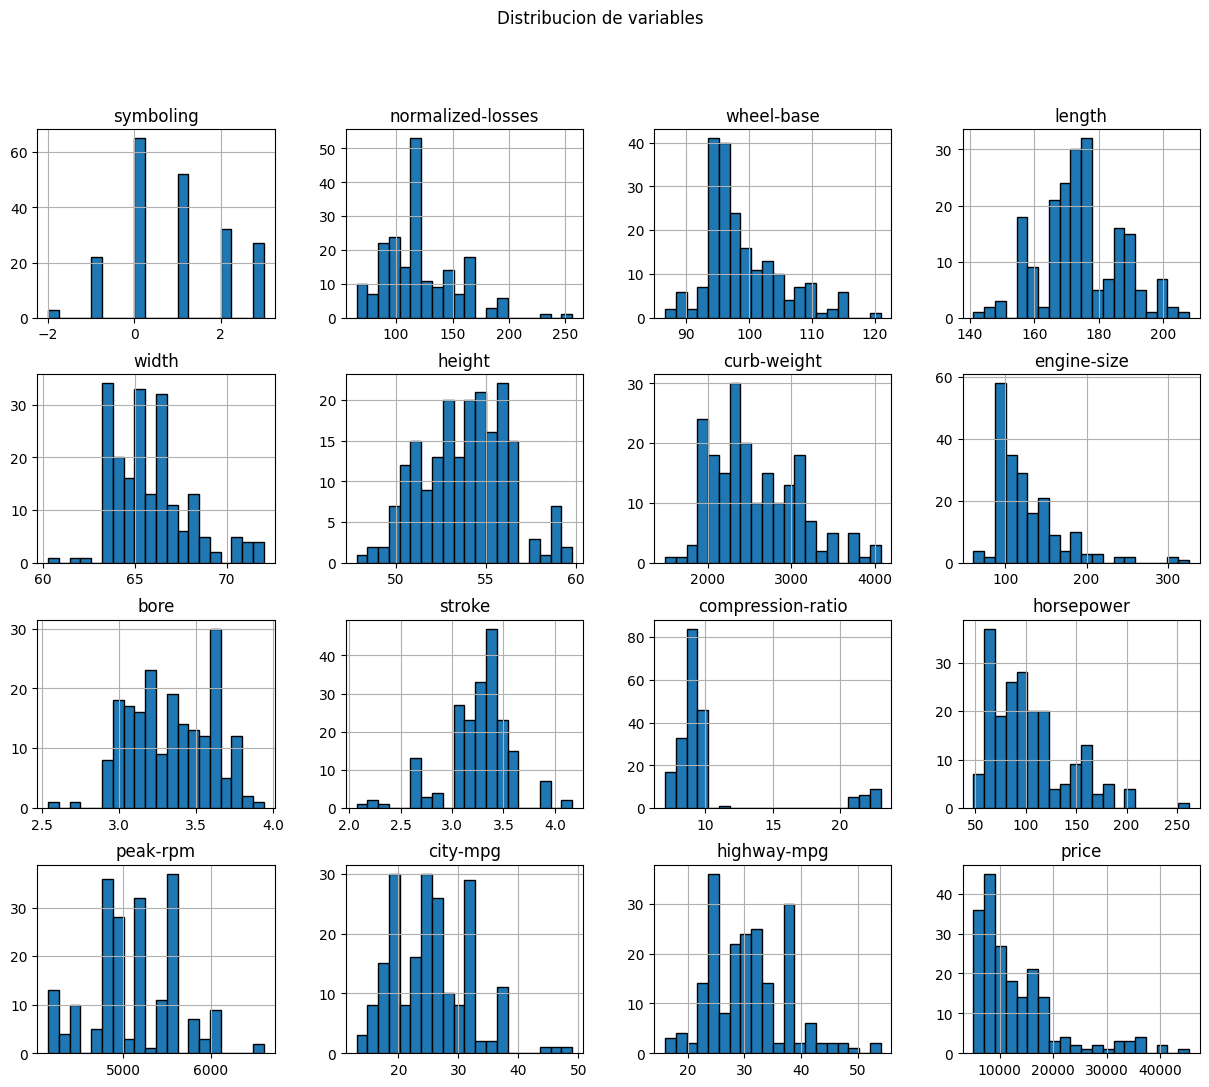

In [13]:
df.hist(figsize=(15,12), bins=20, edgecolor='black')
plt.suptitle('Distribucion de variables')
plt.show()

**Outliers**

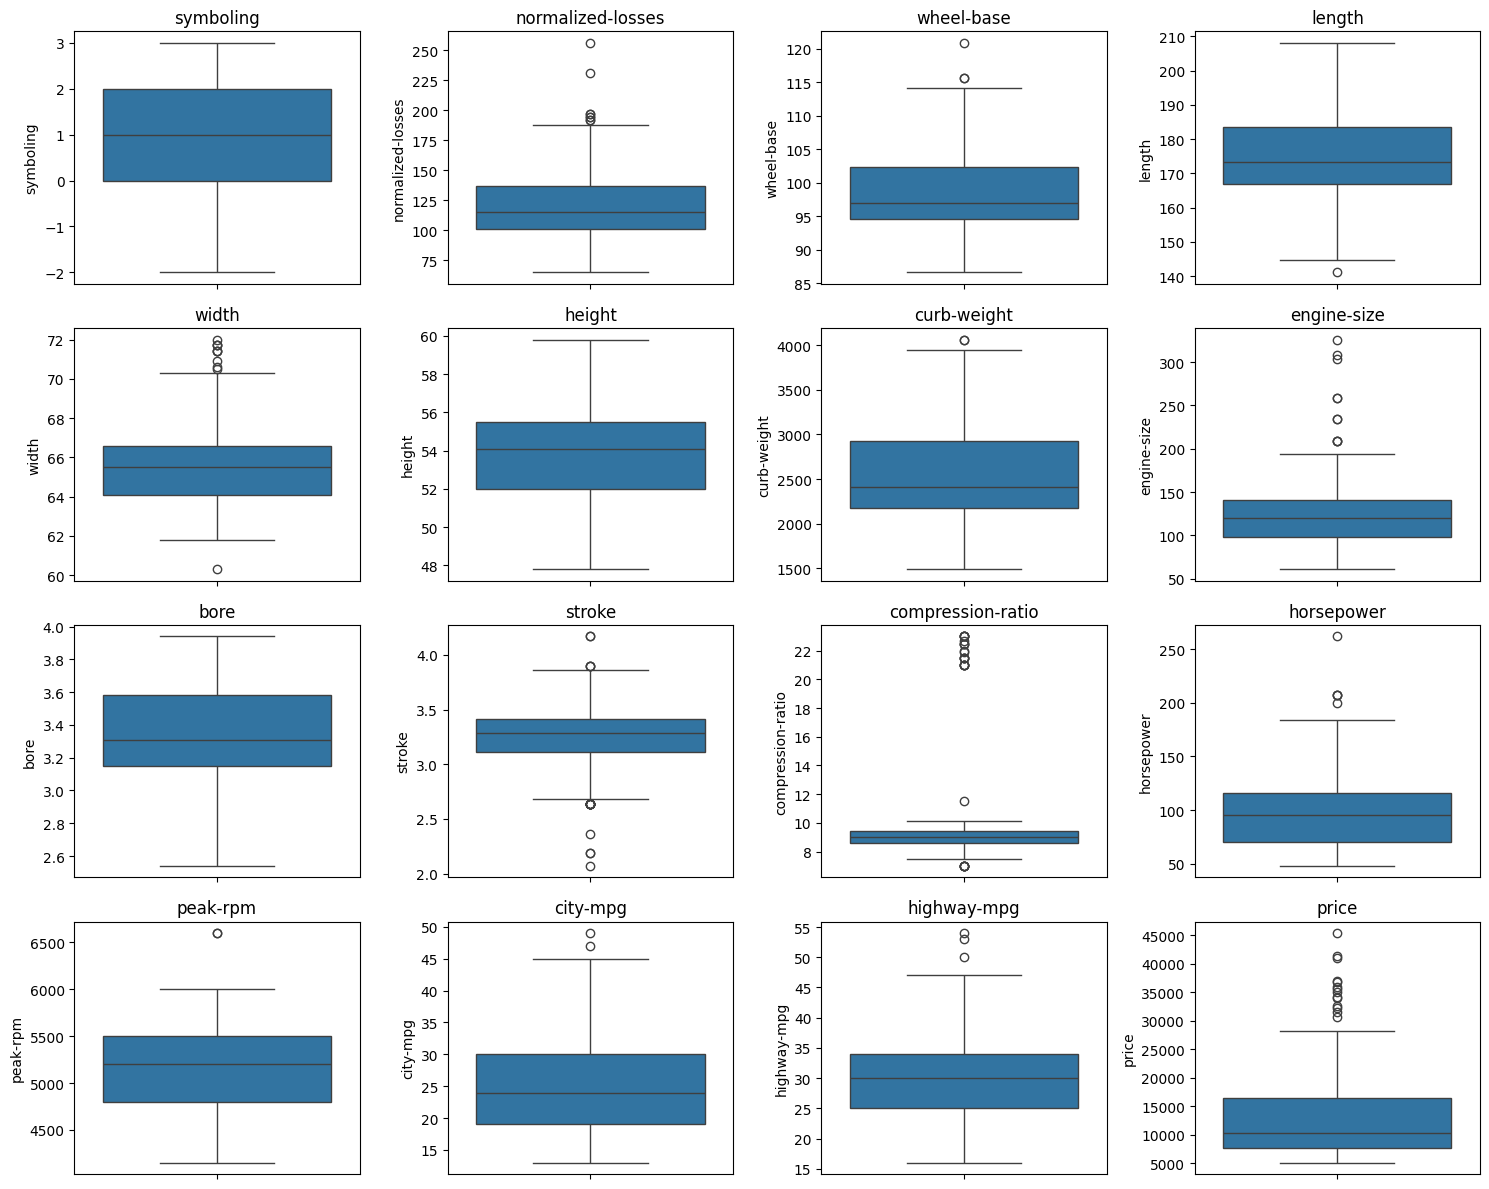

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15,12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Tratamiento Outliers

In [15]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

**Correlaciones**

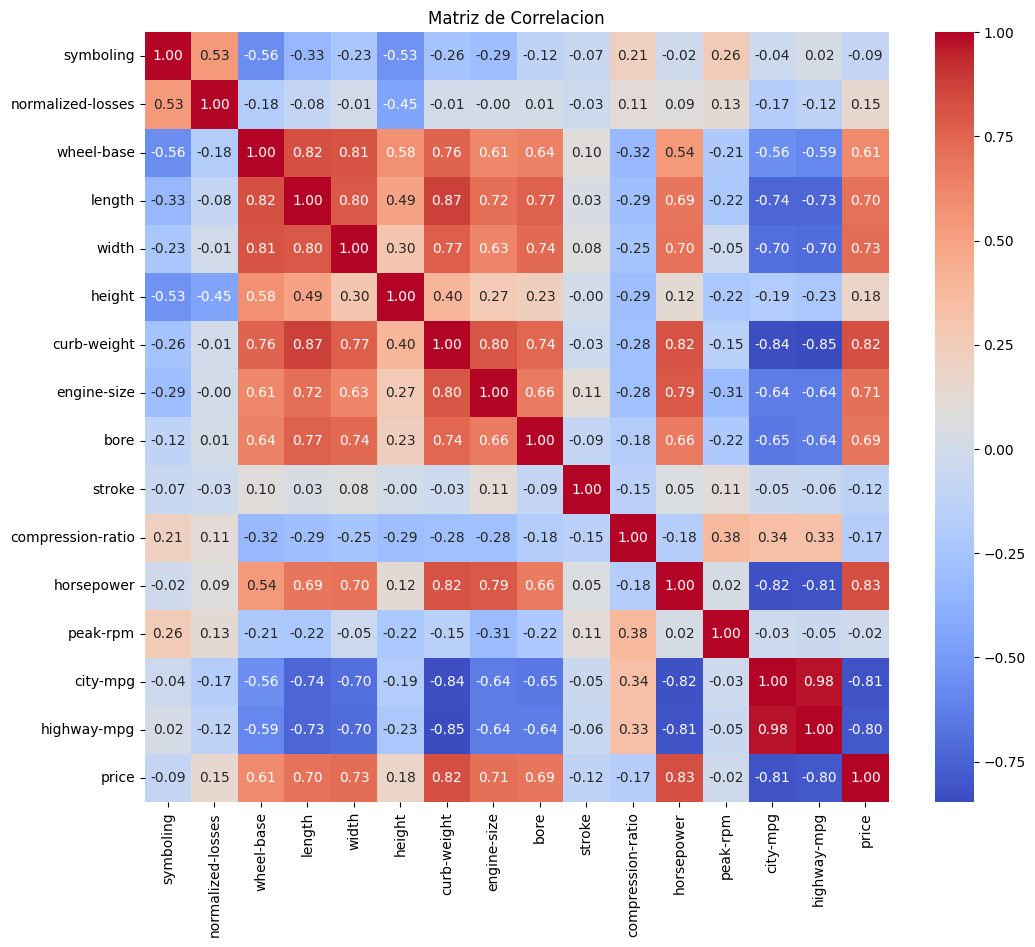

In [16]:
plt.figure(figsize=(12,10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion')
plt.show()

**Conclusiones parte 1 (EDA)**

Durante el analisis exploratorio se identifico que en algunas filas habia un signo de interrogacion (?), por lo tanto se cambio este dato con nan, ademas las columnas normalized-losses, bore, stroke, horsepower, peak.rpm y price estaban con tipo de dato str y debia ser tipo de dato numerico, por lo tanto se realizo la transformacion.
Luego de esto se verifico que no teniamos datos duplicados y se observo que teniamos valores nulos en variables numericas y categoricas. Las variables numericas fueron tratadas mediante imputacion con la mediana debido a la presencia de outliers y distribuciones asimetricas, mientras que la variable categorica num-of-doors fue impuetada utilizando la moda. Ademas, los registros faltantes en la variable price fueron eliminados para asegurar un entrenamiento correcto de los modelos predictivos.

A partir de los histogramas se observo que varia variables numericas presentan distribuciones asimetricas, especialmente potencia del motos, tamaño del vehiculo y precio, esto sugiere que existen autos economicos concentrados en gran cantidad y un menor numero de vehiculos de alto precio.

Los boxplots permitieron identificar presencia de valores atipicos en variables con precio, tamaño de motor, horsepower, curb-weight, esto outliers puden corresponder a vehiculos de lujos, autos deportivos y/o modelos con caracteristicas tecnicas muy superiores al promedio el tratamiento mediante IQR ayudo a reducir el impacto de estos valores extremos sobre los modelos predictivos.

La matriz de correlacion mostro relaciones importantes entre algunas variables y el precio del automovil, como engine-size, horsepower, curb-weight y width que suelen presentar correlaciones positivas relativamente altas con price lo que hace sentido por que autos mas grandes, pesados y con motores mas potentes generalmente tienen precios mas elevados.

Las variables categoricas contienen informacion relavante relacionada con tipo de conbustible, tipo de carroceria, sistema de traccion y marca, estas variables pueden aportar capacidad predictiva importante luego de aplicar codificacion.

El dataset muestra relaciones no lineales entre varias caracteristicas y el precio del automovil, lo que sugiere que modelos como KNN y Arbol de decision podrian capturar mejor ciertos patrones en comparacion con una regresion lineal simple.



**Parte 2**

**Procesamiento**

In [17]:
X = df.drop('price', axis=1)
y = df['price']

In [18]:
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [19]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [20]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numerical_cols), ('cat', categorical_transformer, categorical_cols)])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
linear_model = Pipeline(steps=[('Preprocessor', preprocessor), ('model', LinearRegression())])
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [23]:
knn_model = Pipeline(steps=[('Preprocessor', preprocessor), ('model', KNeighborsRegressor(n_neighbors=10))])
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [24]:
tree_model = Pipeline(steps=[('Preprocessor', preprocessor), ('model', DecisionTreeRegressor(max_depth=8, random_state=42))])
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [25]:
results = pd.DataFrame({'Modelo': ['Regresion Lineal', 'KNN', 'Decision Tree'], 'MSE': [mean_squared_error(y_test, y_pred_linear), mean_squared_error(y_test, y_pred_knn), mean_squared_error(y_test, y_pred_tree)], 'R2': [r2_score (y_test, y_pred_linear), r2_score(y_test, y_pred_knn), r2_score(y_test, y_pred_tree)], 'RMSE': [root_mean_squared_error(y_test, y_pred_linear), root_mean_squared_error(y_test, y_pred_knn), root_mean_squared_error(y_test, y_pred_tree)]})
print(results)

             Modelo           MSE        R2         RMSE
0  Regresion Lineal  5.046327e+06  0.670169  2246.403111
1               KNN  4.377368e+06  0.713893  2092.216083
2     Decision Tree  2.693434e+06  0.823956  1641.168463


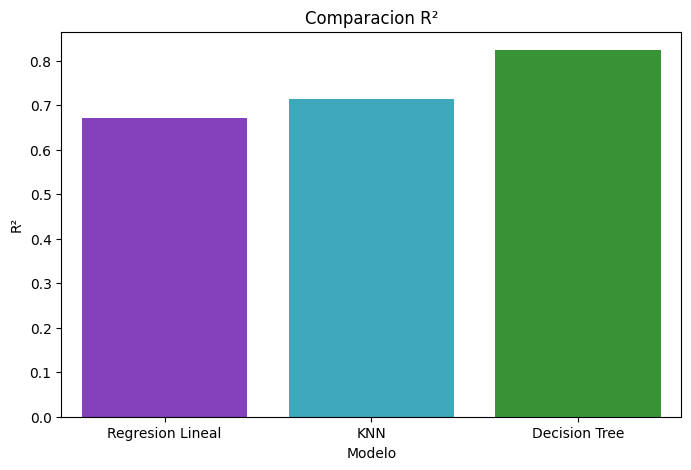

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Modelo', y='R2', hue='Modelo', palette=['#882BCF','#2BB6CF','#29A326'], legend=False)
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.xlabel('Modelo')
plt.show()

**Conclusiones parte 2**

El modelo de arbol de decision obtuvo el merjo desempeño en la prediccion de precios de automoviles, alcanzando el mayor valor de R2. Esto sugiere que el problema presenta relaciones no lineales entre las caracteristicas tecnicas de los vehiculos y su precio. Aunque la regresion lineal logro capturar parte del comportamiento general de los datos, el arbol de decision fue mas eficiente para modelar patrones complejos y segmentaciones presentes en el dataset. El modelo KNN mostro un desempeño intermedio, evidenciando tambien la existencia de similitudes locales entre vehiculos con caracteristicas parecidas.

# **Desafios adicionales**

**Optimización de Modelos**

In [30]:
param_grid_knn = {'model__n_neighbors': [3,5,7,10,15], 'model__weights': ['uniform', 'distance']}
grid_knn =GridSearchCV(knn_model, param_grid_knn, cv=5, scoring='r2')
grid_knn.fit(X_train, y_train)
print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'model__n_neighbors': 3, 'model__weights': 'distance'}
0.6747677979518062


In [32]:
param_grid_tree = {'model__max_depth': [3,5,8,10,None], 'model__min_samples_split': [2,5,10], 'model__min_samples_leaf': [1,2,4]}
grid_tree =GridSearchCV(tree_model, param_grid_tree, cv=5, scoring='r2')
grid_tree.fit(X_train, y_train)
print(grid_tree.best_params_)
print(grid_tree.best_score_)

{'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
0.6880905271433722


Mediante GridSearchCV se optimizaron los hiperparametros de los modelos KNN y arbol de decision ya que fueron los con mejores desempeño.Para KNN, la mejor configuracion fue utilizar 3 vecimos de ponderacion basada en distancia, obteniendo en R2 promedio cercano a 0.675. Por otro lado, el arbol de decision alcanzo el mejor desempeño general con una profundidad maxima de 8, minimo de 4 muentras por hoja y 10 muestras para dividir nodos, logrando un R2 promedio aprox de 0.688. Estos resultados indican que el arbol de decision mantiene un mejor equilibrio entre capacidad predictiva y generalizacion.

**Validacion cruzada**

In [33]:
cv_scores_tree = cross_val_score(tree_model, X, y, cv=5, scoring='r2')
print(cv_scores_tree)
print(cv_scores_tree.mean())

[0.88601288 0.72997729 0.64666216 0.82241892 0.47573271]
0.7121607907221386


In [34]:
cv_scores_knn = cross_val_score(knn_model, X, y, cv=5, scoring='r2')
print(cv_scores_knn)
print(cv_scores_knn.mean())

[0.53509506 0.74355885 0.59708854 0.63640619 0.43741576]
0.5899128812511779


In [35]:
cv_scores_linear = cross_val_score(linear_model, X, y, cv=5, scoring='r2')
print(cv_scores_linear)
print(cv_scores_linear.mean())

[ 0.39512032 -0.14093397 -0.24691536 -0.14183426 -3.85820009]
-0.7985526709853857


Los resultados de validacion cruzada muestran que el arbol de decision fue el modelo con mejor capacidad de generalizacion, alcanzando un R2 promedio aprox de 0.712. Esto indica que el modelo logra explicar mas del 70% de la variabilidad del precio de los automoviles en distintos subconjuntos de datos. El modelo KNN tambien obtuvo resultados positivos, aunque con menor estabilidad y menor desempeño promedio. Por otro lado, la regresion lineal presento resultados negativos e inestables, evidenciando que el problema contiene relaciones no lineales y presencia de outliers que afecta significativamente a modelos lineales tradicionales.

**Feature Engineering**

In [43]:
df['power_to_weight'] = (df['horsepower'] / df['curb-weight'])

df['engine_efficiency'] = (df['horsepower'] / df['engine-size'])

df['avg_mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2

In [44]:
X = df.drop('price', axis=1)
y = df['price']

In [45]:
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
linear_model_fe = Pipeline(steps=[('Preprocessor', preprocessor), ('model', LinearRegression())])
linear_model_fe.fit(X_train, y_train)
y_pred_linear_fe = linear_model_fe.predict(X_test)

In [48]:
knn_model_fe = Pipeline(steps=[('Preprocessor', preprocessor), ('model', KNeighborsRegressor(n_neighbors=10))])
knn_model_fe.fit(X_train, y_train)
y_pred_knn_fe = knn_model_fe.predict(X_test)

In [49]:
tree_model_fe = Pipeline(steps=[('Preprocessor', preprocessor), ('model', DecisionTreeRegressor(max_depth=8, random_state=42))])
tree_model_fe.fit(X_train, y_train)
y_pred_tree_fe = tree_model_fe.predict(X_test)

In [50]:
results_fe = pd.DataFrame({'Modelo': ['Regresion Lineal', 'KNN', 'Decision Tree'], 'MSE': [mean_squared_error(y_test, y_pred_linear_fe), mean_squared_error(y_test, y_pred_knn_fe), mean_squared_error(y_test, y_pred_tree_fe)], 'R2': [r2_score (y_test, y_pred_linear_fe), r2_score(y_test, y_pred_knn_fe), r2_score(y_test, y_pred_tree_fe)], 'RMSE': [root_mean_squared_error(y_test, y_pred_linear_fe), root_mean_squared_error(y_test, y_pred_knn_fe), root_mean_squared_error(y_test, y_pred_tree_fe)]})
print(results_fe)

             Modelo           MSE        R2         RMSE
0  Regresion Lineal  5.046327e+06  0.670169  2246.403111
1               KNN  4.377368e+06  0.713893  2092.216083
2     Decision Tree  2.693434e+06  0.823956  1641.168463


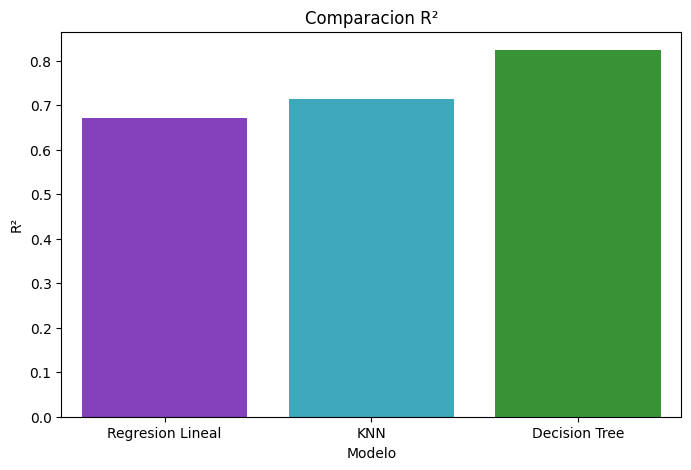

In [51]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_fe, x='Modelo', y='R2', hue='Modelo', palette=['#882BCF','#2BB6CF','#29A326'], legend=False)
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.xlabel('Modelo')
plt.show()

Luego de aplicar tecnicas de Feature Engineering y reentrenar los modelos, no se observaron mejoras significativas en las metricas de desmpeño. Esto sugiere que las variables originales del dataset ya contenian suficiente informacion predictiva para explicar el precio de los automoviles. Ademas, modelos como Arboles de decision son capaces de capturar relaciones complejas e interacciones entre variables de manera automatica, reduciendo el impacto de las nuevas caracteristicas derivadas.